Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [5]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

In [7]:
def getBorderDataBy(gray, img, factor, str):
    """
    Cuenta los píxeles no nulos por filas o por columnas de una imagen binaria y
    resalta sobre `img` las filas/columnas cuya cuenta supera factor * máximo.

    Parámetros:
        gray   -- imagen de bordes en escala de grises (valores 0 o 255) sobre la que se cuenta.
        img    -- imagen BGR sobre la que se dibujan las líneas (se modifica in situ).
        factor -- fracción del máximo a partir de la cual se resalta (p. ej. 0.9).
        str    -- "row" para contar por filas o "col" para contar por columnas.

    Devuelve:
        (img, high_roc, max_val_roc)
        img         -- la imagen con las líneas dibujadas (rojo filas, verde columnas).
        high_roc    -- array (N, 2) con las coordenadas [fila, columna] de `counts`
                       que superan el umbral; el índice útil es la columna 0 para
                       filas y la columna 1 para columnas.
        max_val_roc -- valor máximo de la suma (en unidades de 255 por píxel blanco).
        Si `str` no es válido devuelve None.
    """
    # cv2.reduce: dim=0 reduce a una única fila (suma por columnas),
    #             dim=1 reduce a una única columna (suma por filas)
    roc = 0 if str == "col" else 1 if str == "row" else None
    if roc is None:
        return
    counts = cv2.reduce(gray, roc, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

    # Valor máximo de la cuenta
    max_roc = np.argwhere(counts == counts.max())
    max_val_roc = counts[max_roc[0][0], max_roc[0][1]]

    # Posiciones cuya cuenta es >= factor * máximo
    high_roc = np.argwhere(counts >= max_val_roc*factor)

    # Columnas: línea vertical verde en x; filas: línea horizontal roja en y
    consume = (lambda x : cv2.rectangle(img, (x[1],0), (x[1],512), (0,255,0), 2)) if not roc else (lambda x : cv2.rectangle(img, (0, x[0]), (512, x[0]), (0,0,255), 2))
    for col in high_roc:
        consume(col)
    return (img, high_roc, max_val_roc)

Maxfil:  56100
Numº Filas > 0.9*maxfil:  7
Indices de filas:  [  6  12  15  20  21  88 100]


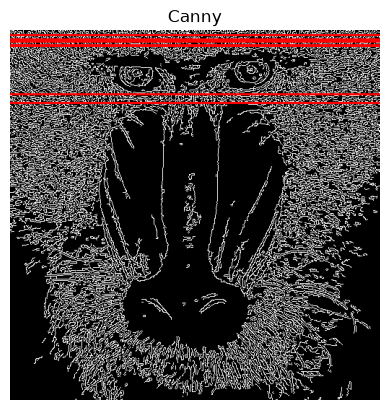

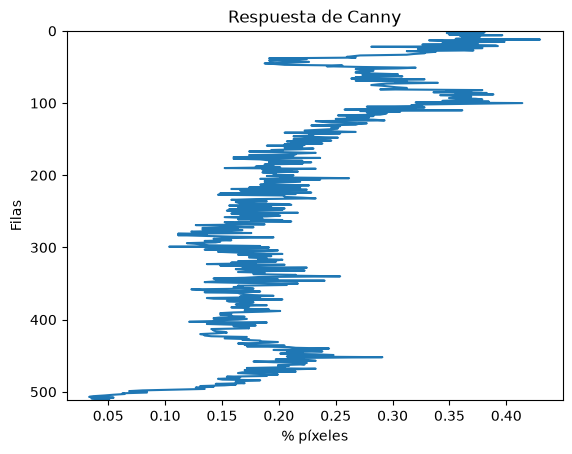

In [8]:
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
#El contenido de la imagen resultado de Canny son valores 0 o 255
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila (dim=1 reduce a una única columna)
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será la proporción de píxeles blancos en cada fila
rows = np.copy(row_counts[:, 0] / (255 * canny.shape[1]))
#Se conserva la imagen binaria para contar y se pasa a BGR para poder dibujar en color
gray = canny
canny = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
canny, high_rows, max_val = getBorderDataBy(gray,canny,0.9,"row")
canny = cv2.cvtColor(canny,cv2.COLOR_BGR2RGB)


#max_val está en unidades de 255 por píxel blanco (56100 / 255 = 220 píxeles)
print("Maxfil: " , max_val)
print("Numº Filas > 0.9*maxfil: " , high_rows.size // 2)
print("Indices de filas: ", np.reshape(high_rows[:,0], high_rows.size //2))

#Muestra dicha cuenta gráficamente
plt.figure()
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')

plt.figure()
plt.title("Respuesta de Canny")
plt.ylabel("Filas")
plt.xlabel("% píxeles")
plt.plot(rows, range(canny.shape[0]))
plt.ylim([canny.shape[0], 0])

plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

In [9]:
def getBorders(img, valorUmbral):
    """
    Calcula los bordes de una imagen BGR con Canny y con Sobel.

    Parámetros:
        img         -- imagen BGR de entrada.
        valorUmbral -- umbral (0-255) aplicado a la magnitud de Sobel en 8 bits.

    Devuelve:
        (canny, sobel8, imagenUmbralizada)
        canny             -- bordes de Canny (umbrales 100 y 200), valores 0/255.
        sobel8            -- respuesta de Sobel convertida a 8 bits (0-255).
        imagenUmbralizada -- sobel8 binarizada con valorUmbral, valores 0/255.
    """
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #Suavizado previo para reducir el ruido antes de derivar
    ggris = cv2.GaussianBlur(gris, (3, 3), 0)
    canny = cv2.Canny(gris, 100, 200)
    sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
    sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
    #Combinación de ambas derivadas y paso a 8 bits (valor absoluto saturado a 255)
    sobel = cv2.add(sobelx, sobely)
    sobel8 = cv2.convertScaleAbs(sobel)
    #Binarización: píxeles por encima del umbral pasan a 255, el resto a 0
    _, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)
    return (canny,sobel8,imagenUmbralizada)

In [10]:
def showBorderData(high_rows, high_cols ,img):
    """
    Muestra por pantalla el número e índices de las filas y columnas destacadas
    y visualiza la imagen con las líneas dibujadas.

    Parámetros:
        high_rows -- array (N, 2) devuelto por getBorderDataBy(..., "row").
        high_cols -- array (M, 2) devuelto por getBorderDataBy(..., "col").
        img       -- imagen BGR con las primitivas ya dibujadas.
    """
    #OpenCV trabaja en BGR y matplotlib en RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Cada posición de argwhere ocupa 2 valores [fila, columna], de ahí el // 2
    print("Numº Filas > 0.9*maxfil: " , high_rows.size // 2)
    print("Indices de filas: ", np.reshape(high_rows[:,0], high_rows.size //2))

    print("Numº Columnas > 0.9*maxcol: " , high_cols.size // 2)
    print("Indices de Columnas: ", np.reshape(high_cols[:,1], high_cols.size //2))

    plt.figure()
    plt.axis("off")
    plt.imshow(img, cmap='gray')

    plt.show()

In [11]:
def getBorderData(img,factor):
    """
    Aplica getBorderDataBy por filas y por columnas sobre una imagen de bordes.

    Parámetros:
        img    -- imagen de bordes en escala de grises (0/255).
        factor -- fracción del máximo a partir de la cual se resalta.

    Devuelve:
        (high_rows, high_cols, img) con img convertida a BGR y con las filas
        (rojo) y columnas (verde) destacadas dibujadas.
    """
    #Se cuenta sobre la imagen original y se dibuja sobre una copia en color
    gray = img
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img, high_rows, _ = getBorderDataBy(gray,img, factor,"row")
    img, high_cols, _ = getBorderDataBy(gray,img, factor,"col")
    return (high_rows,high_cols,img)

Numº Filas > 0.9*maxfil:  7
Indices de filas:  [  6  12  15  20  21  88 100]
Numº Columnas > 0.9*maxcol:  19
Indices de Columnas:  [ 67  86  92  96  99 100 103 104 105 112 115 119 123 379 380 383 392 396
 403]


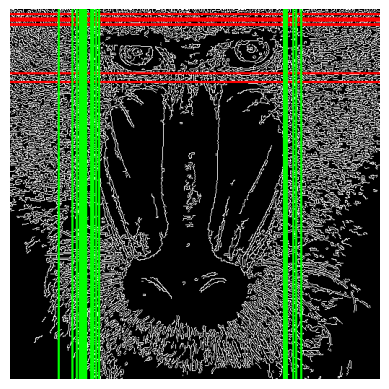

Numº Filas > 0.9*maxfil:  4
Indices de filas:  [ 3  8 82 83]
Numº Columnas > 0.9*maxcol:  5
Indices de Columnas:  [104 105 127 287 288]


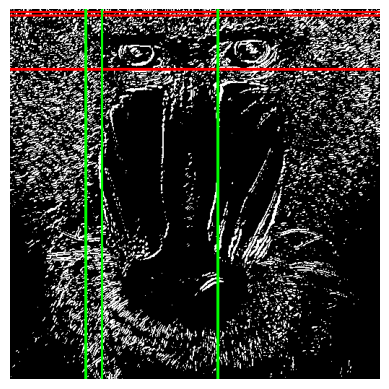

In [12]:
img = cv2.imread('mandril.jpg')
#Umbral de 110 para Sobel y factor 0.9 para ambos métodos
canny,_ , imagenUmbralizada = getBorders(img, 110)
showBorderData(*getBorderData(canny,0.9))
showBorderData(*getBorderData(imagenUmbralizada,0.9))

**¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?**

- **Grosor y continuidad de los bordes.** Canny devuelve bordes de un píxel de ancho y bastante continuos gracias a la supresión de no máximos y a la histéresis con dos umbrales. Sobel umbralizado solo aplica un umbral global a la magnitud del gradiente, por lo que los bordes salen más gruesos y fragmentados.
- **Sensibilidad a la textura.** En el pelaje del mandril Sobel genera muchos trazos cortos (ruido de textura), mientras que en las zonas lisas del hocico apenas detecta bordes. Canny marca contornos más limpios en ambas zonas.
- **Dependencia de la orientación.** Como `sobel = sobelx + sobely` suma las derivadas con signo, en bordes diagonales se pueden compensar y desaparecer.
- **Filas y columnas destacadas.** Con factor 0.9, ambos métodos coinciden en las filas de la frente (filas 3–21) y en la línea de los ojos (filas 82–100). En columnas difieren más: Canny marca 19 columnas agrupadas en los laterales del pelaje (67–123 y 379–403), y Sobel solo 5 (104–105, 127, 287–288). Como Canny produce más píxeles blancos en las zonas de pelo, sus máximos son más estables y aparecen agrupados.
- **Parámetros.** El resultado de Sobel depende mucho del umbral elegido (110 en este caso): si se baja, aparece mucho ruido, y si se sube, se pierden bordes. En el demostrador con cámara, las barras *Umbral* y *Factor* permiten comprobarlo en vivo.

En resumen, Canny da una detección de bordes más precisa y robusta, y Sobel umbralizado es más simple y rápido, pero más ruidoso y sensible a la elección del umbral.

In [15]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]
#Ventana con trackbars para ajustar en vivo el umbral de Sobel y el factor del máximo
cv2.namedWindow('Cam')
cv2.createTrackbar('Umbral', 'Cam', 100, 240, lambda v: None)
cv2.createTrackbar('Factor', 'Cam', 90, 100, lambda v: None)

while True:
    # fotograma a fotograma
    ret, frameIN = vid.read()
    #Valores mínimos para evitar umbrales que marquen prácticamente toda la imagen
    umbral = max(20, cv2.getTrackbarPos('Umbral', 'Cam'))
    factor = max(0.40, cv2.getTrackbarPos('Factor', 'Cam') / 100)

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Bordes y filas/columnas destacadas para Canny, Sobel y Sobel umbralizado
        canny,sobel8,imagenUmbralizada = getBorders(frame, umbral)
        _,_, canny = getBorderData(canny, factor)
        _,_, sobel8 = getBorderData(sobel8,factor)
        _,_, imagenUmbralizada = getBorderData(imagenUmbralizada,factor)

        #Collage: original | Canny / Sobel | Sobel umbralizado
        tr[:,:,:] = canny[:,:,:]
        tl[:,:,:] = frame[:,:,:]
        bl[:,:,:] = sobel8[:,:,:]
        br[:,:,:] = imagenUmbralizada[:,:,:]
        cv2.imshow('Cam', collage)

    # Detenemos pulsando ESC o q (una sola lectura de teclado por fotograma)
    tecla = cv2.waitKey(20) & 0xFF
    if tecla == 27 or tecla == ord('q'):
        break

vid.release()
cv2.destroyAllWindows()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

Antes de poder ejecutar la tarea, necesitamos hacer la siguiente instalación:

In [16]:
%pip install sounddevice soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.2 MB/s  0:00:01m 1.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sounddevice]
Note: you may need to restart the kernel to use updated packages.


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import sounddevice as sd
import soundfile as sf

# Demostrador: control de la música con las manos.
# Mano en la zona izquierda -> volumen; mano en la zona derecha -> velocidad.
# La mano se detecta segmentando color de piel en YCrCb y se mide la altura de su punto más alto.

AUDIO = "musica.mp3"      # archivo de audio de fondo (mp3, wav, ogg, flac)

MIN_PIXELES_ZONA = 5000   # píxeles para considerar una zona ocupada
MIN_PIXELES_FILA = 15     # píxeles de piel que debe tener una fila para contar como mano
CAJA = 80                 # lado del cuadrado de calibración
MEZCLA = 0.5              # cuánto se acerca a la muestra en cada calibración
ANCHO_MIN = 30            # ancho mínimo del rango de Cr y Cb

# Márgenes de altura: por debajo de MARGEN_INF cuenta como 0 % y por encima de MARGEN_SUP como 100 %
MARGEN_INF, MARGEN_SUP = 0.15, 0.85
SUAVIZADO = 0.2           # 0-1: cuanto más bajo, más lento y estable responde el control
ZONA_MUERTA = 0.02        # cambios menores que esto se ignoran (temblores)

# Rango de piel en YCrCb: [Y, Cr, Cb]
INICIAL = (np.array([0, 133, 77.]), np.array([255, 173, 127.]))
lowerBound, upperBound = INICIAL[0].copy(), INICIAL[1].copy()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))


def altura_mano(zona):
    """Porcentaje (0-1) de altura del punto más alto de la mano, o None si no hay mano."""
    if cv2.countNonZero(zona) < MIN_PIXELES_ZONA:
        return None
    filas = np.flatnonzero(np.count_nonzero(zona, axis=1) > MIN_PIXELES_FILA)
    if len(filas) == 0:
        return None
    altura = 1 - filas[0] / zona.shape[0]
    return float(np.clip((altura - MARGEN_INF) / (MARGEN_SUP - MARGEN_INF), 0, 1))


def a_velocidad(p):
    """0 % -> x0.25, 50 % -> x1, 100 % -> x2."""
    return 0.25 + p * 1.5 if p < 0.5 else 1 + (p - 0.5) * 2


# Audio de fondo: se carga entero en memoria y se reproduce en bucle
datos, frecuencia = sf.read(AUDIO, dtype="float32", always_2d=True)
audio = {"pos": 0.0, "volumen": 1.0, "velocidad": 1.0}


def callback(salida, n, tiempo, estado):
    """Rellena cada bloque de audio avanzando por el archivo a la velocidad actual."""
    idx = (audio["pos"] + np.arange(n) * audio["velocidad"]) % len(datos)
    i0 = idx.astype(int)
    frac = (idx - i0)[:, None]
    # Interpolación lineal entre muestras vecinas para velocidades no enteras
    salida[:] = (datos[i0] * (1 - frac) + datos[(i0 + 1) % len(datos)] * frac) * audio["volumen"]
    audio["pos"] = (audio["pos"] + n * audio["velocidad"]) % len(datos)


stream = sd.OutputStream(samplerate=frecuencia, channels=datos.shape[1], callback=callback)
stream.start()
controles = [1.0, 0.5]           # [volumen, velocidad] en 0-1 (velocidad 0.5 = x1)

cap = cv2.VideoCapture(0)
ver_camara = True

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    h, w = frame.shape[:2]
    ycrcb = cv2.cvtColor(cv2.GaussianBlur(frame, (7, 7), 0), cv2.COLOR_BGR2YCrCb)

    # Máscara de piel limpia de ruido
    mascara = cv2.inRange(ycrcb, lowerBound.astype(np.uint8), upperBound.astype(np.uint8))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel, iterations=2)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Conteo de píxeles en tres zonas
    vista = frame.copy() if ver_camara else cv2.cvtColor(mascara, cv2.COLOR_GRAY2BGR)
    for i, nombre in enumerate(["Izquierda", "Centro", "Derecha"]):
        n = cv2.countNonZero(mascara[:, i * w // 3:(i + 1) * w // 3])
        color = (0, 255, 0) if n > MIN_PIXELES_ZONA else (0, 0, 255)
        cv2.putText(vista, f"{nombre}: {n}", (10 + i * w // 3, h - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cv2.line(vista, (i * w // 3, 0), (i * w // 3, h), (255, 255, 0), 1)

    # Altura de la mano en las zonas izquierda (volumen) y derecha (velocidad)
    for i, x0 in enumerate((0, 2 * w // 3)):
        p = altura_mano(mascara[:, x0:x0 + w // 3])
        if p is not None and abs(p - controles[i]) > ZONA_MUERTA:
            controles[i] += SUAVIZADO * (p - controles[i])   # suavizado exponencial

        # Márgenes y nivel actual dibujados en la zona
        for m in (MARGEN_INF, MARGEN_SUP):
            ym = int(h * (1 - m))
            cv2.line(vista, (x0, ym), (x0 + w // 3, ym), (128, 128, 128), 1)
        yn = int(h * (1 - (MARGEN_INF + controles[i] * (MARGEN_SUP - MARGEN_INF))))
        cv2.line(vista, (x0, yn), (x0 + w // 3, yn), (0, 200, 255), 2)

    volumen, velocidad = controles
    cv2.putText(vista, f"Volumen: {volumen * 100:.0f}%", (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)
    cv2.putText(vista, f"Velocidad: x{a_velocidad(velocidad):.2f}", (2 * w // 3 + 10, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)

    audio["volumen"], audio["velocidad"] = volumen, a_velocidad(velocidad)

    # Cuadrado de calibración
    x, y = (w - CAJA) // 2, (h - CAJA) // 2
    cv2.rectangle(vista, (x, y), (x + CAJA, y + CAJA), (255, 0, 255), 2)
    cv2.putText(vista, "c: calibrar  +/-: rango  r: reiniciar  v: vista  q: salir", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 255), 1)
    cv2.imshow("Imagen", vista)

    tecla = cv2.waitKey(20) & 0xFF
    if tecla == ord('c'):
        # Acercar el rango al color dentro del cuadrado (mediana ± dispersión)
        muestra = ycrcb[y:y + CAJA, x:x + CAJA].reshape(-1, 3)
        centro = np.median(muestra, axis=0)
        mitad = np.maximum(np.percentile(muestra, 90, axis=0) - centro + 12, ANCHO_MIN / 2)
        lowerBound = (1 - MEZCLA) * lowerBound + MEZCLA * (centro - mitad)
        upperBound = (1 - MEZCLA) * upperBound + MEZCLA * (centro + mitad)
    elif tecla in (ord('+'), ord('=')):
        lowerBound, upperBound = lowerBound - 2, upperBound + 2
    elif tecla == ord('-') and np.all(upperBound[1:] - lowerBound[1:] > 8):
        lowerBound, upperBound = lowerBound + 2, upperBound - 2
    elif tecla == ord('r'):
        lowerBound, upperBound = INICIAL[0].copy(), INICIAL[1].copy()
    elif tecla == ord('v'):
        ver_camara = not ver_camara
    elif tecla == 27 or tecla == ord('q'):
        break

    if tecla in map(ord, "c+=-r"):
        lowerBound = np.clip(lowerBound, 0, 255); upperBound = np.clip(upperBound, 0, 255)
        lowerBound[0], upperBound[0] = 0, 255

stream.stop()
stream.close()
cap.release()
cv2.destroyAllWindows()

**Propuesta: control de la música con las manos**

Partiendo de *Virtual air guitar* y *Messa di voce*, donde el cuerpo del usuario controla el sonido, se propone un demostrador en el que la altura de las manos frente a la cámara controla la reproducción de una canción.

**Procesamiento de la imagen**
1. Cada fotograma se invierte horizontalmente (efecto espejo), se suaviza con un filtro gaussiano y se convierte a **YCrCb**, un espacio de color en el que la piel ocupa un rango compacto de Cr y Cb, con independencia de la iluminación (Y).
2. Se obtiene una **máscara de piel** con `cv2.inRange` y se limpia con apertura y cierre morfológicos.
3. La imagen se divide en **tres zonas verticales** y en cada una se cuentan los píxeles de piel, de forma similar al conteo por filas y columnas de las tareas anteriores. Una zona se considera ocupada si supera `MIN_PIXELES_ZONA`.
4. En las zonas izquierda y derecha se busca la **primera fila** con suficientes píxeles de piel (punto más alto de la mano) y se convierte a un porcentaje de 0 a 1 entre los márgenes `MARGEN_INF` y `MARGEN_SUP`.
5. El valor se filtra con **suavizado exponencial** y una **zona muerta** para evitar temblores.

**Control del audio**
- Zona izquierda → **volumen** (0–100 %).
- Zona derecha → **velocidad de reproducción** (x0.25 – x2). El audio se reproduce en bucle con `sounddevice` y se remuestrea con interpolación lineal en el *callback*.

**Teclas**
| Tecla | Acción |
|---|---|
| `c` | Calibrar el color de piel con la muestra del cuadrado central |
| `+` / `-` | Ampliar / reducir el rango de color |
| `r` | Restaurar el rango inicial |
| `v` | Alternar entre la cámara y la máscara |
| `q` / `ESC` | Salir |